<a href="https://colab.research.google.com/github/zachnelson275/CSE450/blob/main/Module_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import kagglehub

In [20]:
books = pd.read_csv('library_data.csv')
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   user_id             1000 non-null   object
 1   book_id             1000 non-null   object
 2   borrow_date         1000 non-null   object
 3   return_date         1000 non-null   object
 4   reservation_status  1000 non-null   bool  
 5   overdue_status      1000 non-null   int64 
 6   user_role           1000 non-null   object
 7   book_category       1000 non-null   object
dtypes: bool(1), int64(1), object(6)
memory usage: 55.8+ KB


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

def engineer_features(df):
    df = df.copy()

    # Dates
    df["borrow_date"] = pd.to_datetime(df["borrow_date"])
    df["return_date"] = pd.to_datetime(df["return_date"])

    df["loan_duration"] = (df["return_date"] - df["borrow_date"]).dt.days
    df["borrow_day"] = df["borrow_date"].dt.dayofweek
    df["borrow_month"] = df["borrow_date"].dt.month

    # Frequency features
    df["user_freq"] = df["user_id"].map(df["user_id"].value_counts())
    df["book_popularity"] = df["book_id"].map(df["book_id"].value_counts())

    # Sort for time-based features
    df = df.sort_values(by=["user_id", "borrow_date"])

    # Expanding avg duration
    df["user_avg_duration"] = (
        df.groupby("user_id")["loan_duration"]
        .expanding()
        .mean()
        .shift()
        .reset_index(level=0, drop=True)
    )

    # Fill NaNs
    df["user_avg_duration"].fillna(df["loan_duration"].mean(), inplace=True)

    return df

In [22]:
books = engineer_features(books)

/tmp/ipykernel_34717/3537229245.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["user_avg_duration"].fillna(df["loan_duration"].mean(), inplace=True)


In [23]:
X = books.drop(columns=["overdue_status", "user_id", "book_id"])
y = books["overdue_status"]

categorical = ["user_role", "book_category"]

numerical = [
    "borrow_day",
    "borrow_month",
    "loan_duration",
    "user_freq",
    "book_popularity",
    "user_avg_duration"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numerical)
    ]
)

model = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['user_role',
                                                   'book_category']),
                                                 ('num', 'passthrough',
                                                  ['borrow_day', 'borrow_month',
                                                   'loan_duration', 'user_freq',
                                                   'book_popularity',
                                                   'user_avg_duration'])])),
                ('clf', RandomForestClassifier())])

Feature Importances:


,Feature,Importance
10,loan_duration,0.897117
13,user_avg_duration,0.030502
9,borrow_month,0.024198
8,borrow_day,0.023837
2,user_role_student,0.003752
1,user_role_staff,0.003362
5,book_category_history,0.003337
6,book_category_non-fiction,0.003261
3,book_category_art,0.003103
7,book_category_science,0.002810


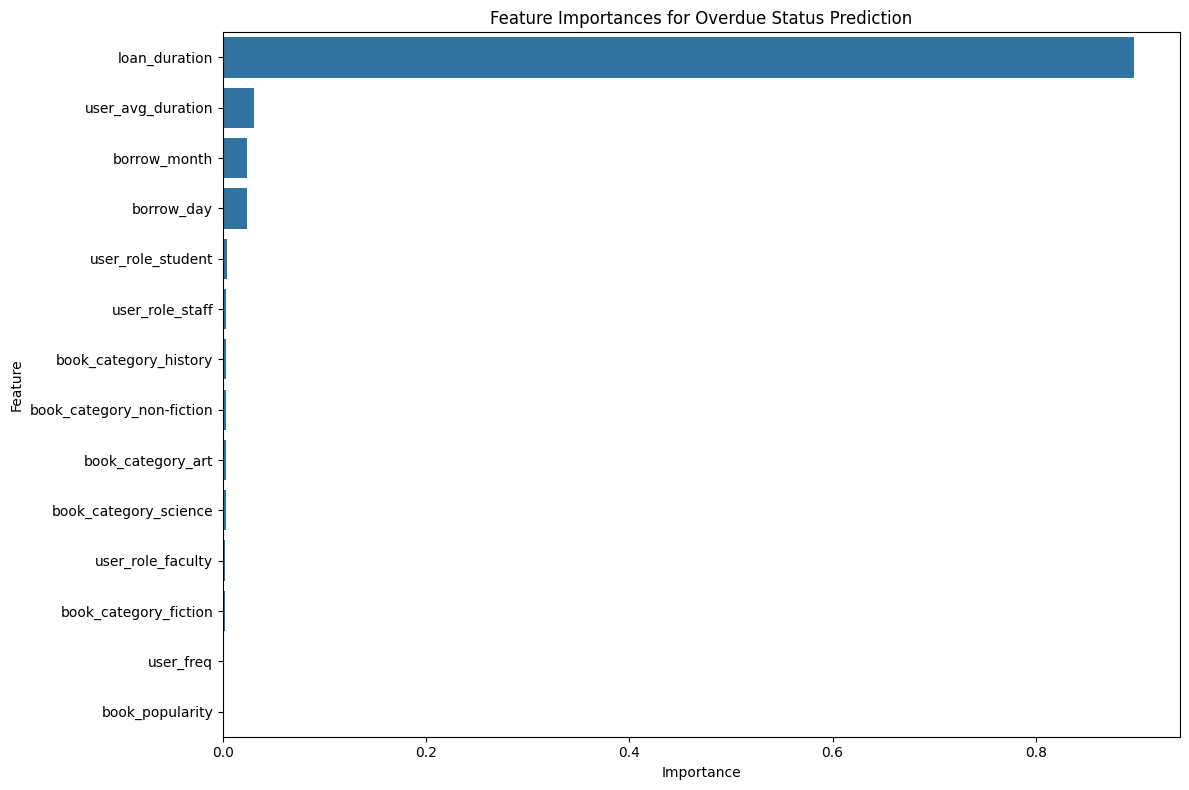

In [24]:
feature_importances = model.named_steps['clf'].feature_importances_

# Get feature names from the preprocessor
onehot_features = model.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical)
all_features = list(onehot_features) + numerical

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(importance_df)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances for Overdue Status Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()